## 📋 Instructions Before Running This Code

Before you begin training or running any code in this file, please make sure to read the following first:

---

### 1. 📁 Download the Latest Dataset from Roboflow and Prepare Your Dataset Folder

- Go to your dataset project in **Roboflow**.
- Make sure to check if they annotated properly.
- Choose the Version needed (usually the latest or most recent version).
- Click **Download Dataset**.  
- Select **YOLOv8** as the format and choose **Download as ZIP**.  

You must have a folder containing your **raw YOLO training data**. The required folder structure is:

``` yolo_dataset_noaug/ 
    └── train/ 
    ├── images/ 
    │ ├── image1.jpg 
    │ ├── image2.jpg 
    │ └── ... 
    └── labels/ 
    ├── image1.txt 
    ├── image2.txt 
    └── ... 
```
- `yolo_dataset_noaug` is the main dataset folder.
- Inside it, the `train` folder must contain two subfolders:
  - `images/`: containing all raw images.
  - `labels/`: containing corresponding YOLO-format label files.
- running the codes will create new folders.
- check the dataset from time to time to make sure there are no problems like duplicates, different filenames, etc.


### 2. 🧠 Training or Running the Code

Once the dataset folder is correctly set up as shown above, you can proceed to run the code in this file.

---

### 3. ⚠️ TFLite Conversion Not Included

Currently, **TFLite conversion is not included** in this code due to compatibility issues with some required packages/libraries on my system.

If you need to convert the `.pt` model to `.tflite`, you can:

- Upload your `.pt` model file to your **Google Drive**
- Use the following **Google Colab notebook** to perform the conversion:

👉 [TFLite Conversion Colab](https://colab.research.google.com/drive/1YeJnFARxYD2Di04awZCqV5OyOHuXxUyq?usp=sharing)


In [1]:
# Preprocessing Data
import os
import numpy as np
import cv2
from tqdm import tqdm
from scipy import special
import shutil

def k_gamma_function(z, k=2):
    """
    Implements the k-Gamma function: Γ_k(z) = k^(z/k - 1) * Γ(z/k)
    
    Parameters:
    -----------
    z : float
        Input value
    k : float
        The k parameter
        
    Returns:
    --------
    float : k-Gamma function value
    """
    return k**(z/k - 1) * special.gamma(z/k)

def k_mittag_leffler(r, rho, k=2, max_terms=50):
    """
    Computes the k-Mittag-Leffler function as shown in equation (9)
    E^(1,1-ρ/k)_k(r)
    
    Parameters:
    -----------
    r : float
        Pixel probability value (0-1)
    rho : float
        Fractional order parameter
    k : float
        The k parameter
    max_terms : int
        Maximum number of terms in the summation
        
    Returns:
    --------
    float : k-Mittag-Leffler function value
    """
    # STEP 4: Using Eq. (9) to determine the proposed K-CFDO
    # Initialize the summation
    result = 0
    
    # Compute the series as per equation (9)
    for n in range(max_terms):
        # r^n / (n! * Γ_k(1+n-ρ/k))
        numerator = r**n
        denominator = np.math.factorial(n) * k_gamma_function(1 + n - rho/k, k)
        term = numerator / denominator
        result += term
        
        # Stop if terms become very small
        if abs(term) < 1e-10:
            break
    
    # Multiply by r^(1-ρ/k) as in equation (9)
    result *= r**(1 - rho/k)
    
    return result

def calculate_pixel_probability(image):
    """
    Calculate the probability value (r) for each pixel
    For simplicity, normalized pixel intensity is used as probability
    
    Parameters:
    -----------
    image : ndarray
        Input grayscale image
        
    Returns:
    --------
    ndarray : Probability map with same shape as input
    """
    # STEP 3: Determine the pixel's probability value (r)
    # Normalize to [0,1] range
    if image.max() > 1.0:
        normalized = image.astype(np.float64) / 255.0
    else:
        normalized = image.astype(np.float64)
    
    return normalized

def k_cfdo_enhancement_full(image, rho=0.5, k=2, window_size=3):
    """
    Complete implementation of K-CFDO enhancement following all algorithm steps
    
    Parameters:
    -----------
    image : ndarray
        Input grayscale image
    rho : float
        Fractional order parameter
    k : float
        The k parameter
    window_size : int
        Size of the window for neighborhood processing
        
    Returns:
    --------
    ndarray : Enhanced image
    """
    # STEP 1: Consider the source image (already done - input parameter)
    img = image.astype(np.float64)
    
    # STEP 2: Set the parameters of ρ and k (done via function parameters)
    
    # STEP 3: Determine the pixel's probability value (r)
    r_map = calculate_pixel_probability(img)
    
    # Create output image
    n, m = img.shape
    enhanced_img = np.zeros_like(img)
    
    # Pad the image for window processing
    pad_width = window_size // 2
    padded_img = np.pad(img / 255.0, pad_width, mode='reflect')
    padded_r = np.pad(r_map, pad_width, mode='reflect')
    
    # STEP 5: Calculate the enhanced image using Eq. (10)
    # Loop through each pixel in the original image
    for i in range(n):
        for j in range(m):
            # Initialize enhancement value
            enhancement = 0
            
            # Apply the double summation as shown in Eq. (10)
            for di in range(window_size):
                for dj in range(window_size):
                    # Get pixel position in padded image
                    pi = i + di
                    pj = j + dj
                    
                    # Get pixel value and probability
                    pixel_value = padded_img[pi, pj]
                    r_value = padded_r[pi, pj]
                    
                    # Calculate terms from Eq. (10)
                    r_term = r_value**(1 - rho/k)
                    gamma_term = k_gamma_function(2 - rho/k, k)
                    
                    # Add to the enhancement value
                    enhancement += pixel_value * r_term / gamma_term
            
            # Store the enhanced pixel value
            enhanced_img[i, j] = enhancement
    
    # Normalize the enhanced image
    if enhanced_img.min() != enhanced_img.max():
        enhanced_img = (enhanced_img - enhanced_img.min()) / (enhanced_img.max() - enhanced_img.min())
    
    return (enhanced_img * 255).astype(np.uint8)

def process_images(input_dir, output_dir, rho=0.7, k=1.0):
    """
    Process all images in the input directory and save to output directory
    
    Parameters:
    -----------
    input_dir : str
        Path to directory containing input images
    output_dir : str
        Path to directory where enhanced images will be saved
    rho : float
        Fractional order parameter
    k : float
        The k parameter
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Get list of image files
    image_files = [f for f in os.listdir(input_dir) if os.path.isfile(os.path.join(input_dir, f)) and 
                  f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'))]
    
    if not image_files:
        print(f"No images found in {input_dir}")
        return
    
    print(f"Processing {len(image_files)} images with rho={rho}, k={k}...")
    
    # Process each image
    for img_file in tqdm(image_files):
        # Read image
        img_path = os.path.join(input_dir, img_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if img is None:
            print(f"Could not read image: {img_path}")
            continue
            
        # Enhance image
        enhanced_img = k_cfdo_enhancement_full(img, rho=rho, k=k)
        
        # Save enhanced image
        output_path = os.path.join(output_dir, img_file)
        cv2.imwrite(output_path, enhanced_img)

def copy_labels(input_label_dir, output_label_dir):
    """
    Copy all label files from input directory to output directory
    
    Parameters:
    -----------
    input_label_dir : str
        Path to directory containing input labels
    output_label_dir : str
        Path to directory where labels will be copied
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_label_dir, exist_ok=True)
    
    # If input directory doesn't exist or is not a directory
    if not os.path.exists(input_label_dir) or not os.path.isdir(input_label_dir):
        print(f"Input label directory does not exist: {input_label_dir}")
        return
    
    # Copy all files from input to output
    label_files = [f for f in os.listdir(input_label_dir) if os.path.isfile(os.path.join(input_label_dir, f))]
    
    if not label_files:
        print(f"No label files found in {input_label_dir}")
        return
    
    print(f"Copying {len(label_files)} label files...")
    
    for label_file in tqdm(label_files):
        src_path = os.path.join(input_label_dir, label_file)
        dst_path = os.path.join(output_label_dir, label_file)
        shutil.copy2(src_path, dst_path)

# Main execution
if __name__ == "__main__":
    # Directories
    input_image_dir = "yolo_dataset_noaug/train/images"
    input_label_dir = "yolo_dataset_noaug/train/labels"
    output_dir = "yolo_dataset_enhanced"
    output_image_dir = os.path.join(output_dir, "images")
    output_label_dir = os.path.join(output_dir, "labels")
    
    # Fixed parameters
    rho = 0.7
    k = 1.0
    
    # Process images
    process_images(input_image_dir, output_image_dir, rho=rho, k=k)
    
    # Copy labels
    copy_labels(input_label_dir, output_label_dir)
    
    print("Processing complete!")
    print(f"Enhanced images saved to: {output_image_dir}")
    print(f"Labels copied to: {output_label_dir}")

Processing 651 images with rho=0.7, k=1.0...


100%|██████████| 651/651 [1:01:27<00:00,  5.66s/it]


Copying 651 label files...


100%|██████████| 651/651 [00:13<00:00, 47.37it/s]

Processing complete!
Enhanced images saved to: yolo_dataset_enhanced\images
Labels copied to: yolo_dataset_enhanced\labels


Sample image: 007_bmp.rf.38af96e631474117d1cc391d921981d7.jpg
Sample label: 007_bmp.rf.38af96e631474117d1cc391d921981d7.txt


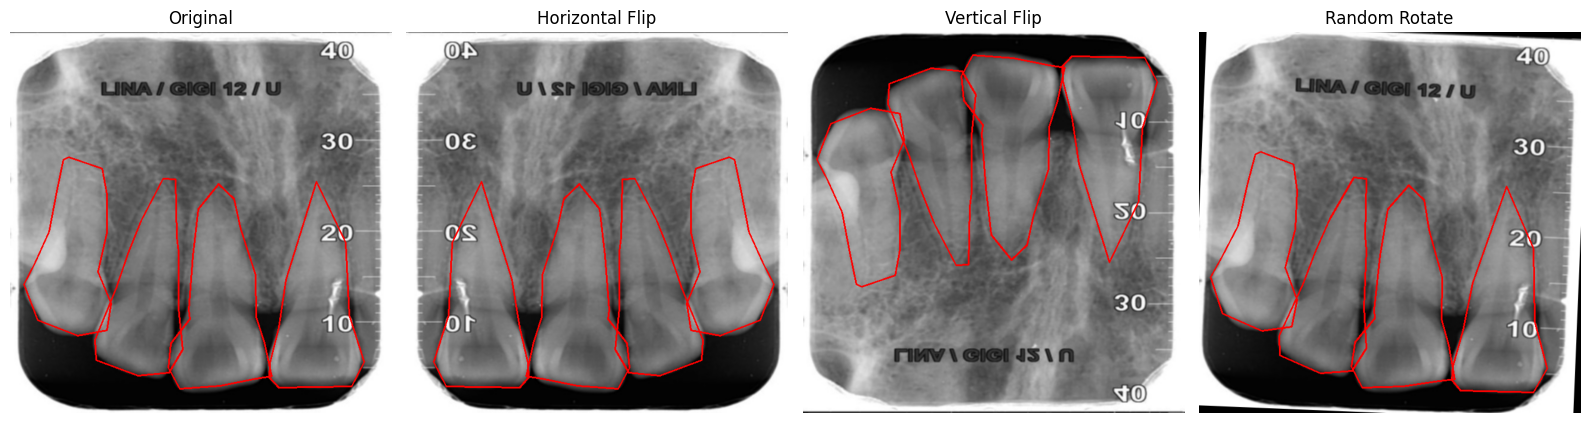

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import random
from pathlib import Path
from shutil import copyfile

# === Paths ===
DATASET_DIR = Path("yolo_dataset_enhanced")
IMG_DIR = DATASET_DIR / "images"
LBL_DIR = DATASET_DIR / "labels"

# === Load any image ===
image_paths = []
for ext in ('*.jpg', '*.jpeg', '*.png'):
    image_paths.extend(IMG_DIR.glob(ext))

if not image_paths:
    raise FileNotFoundError(f"No image files found in {IMG_DIR}")

sample_img_path = random.choice(image_paths)
sample_lbl_path = LBL_DIR / (sample_img_path.stem + ".txt")

print(f"Sample image: {sample_img_path.name}")
print(f"Sample label: {sample_lbl_path.name}")

# === Load image ===
image = cv2.imread(str(sample_img_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
h, w = image.shape[:2]

# === Parse YOLO segmentation-style label ===
def load_polygon_label(label_path):
    polygons = []
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 4:
                continue  # Skip malformed
            cls = int(parts[0])
            coords = list(map(float, parts[1:]))
            points = np.array(coords).reshape(-1, 2)
            abs_points = points * np.array([w, h])  # scale back to pixels
            polygons.append((cls, abs_points))
    return polygons

# === Drawing function ===
def draw_polygons(image, polygons, color=(255, 0, 0)):
    overlay = image.copy()
    for cls, poly in polygons:
        poly = poly.astype(np.int32)
        cv2.polylines(overlay, [poly], isClosed=True, color=color, thickness=2)
    return overlay

# === Augmentations ===
def hflip(image, polygons):
    flipped = cv2.flip(image, 1)
    h, w = image.shape[:2]
    new_polygons = []
    for cls, poly in polygons:
        flipped_poly = poly.copy()
        flipped_poly[:, 0] = w - flipped_poly[:, 0]
        new_polygons.append((cls, flipped_poly))
    return flipped, new_polygons

def vflip(image, polygons):
    flipped = cv2.flip(image, 0)
    h, w = image.shape[:2]
    new_polygons = []
    for cls, poly in polygons:
        flipped_poly = poly.copy()
        flipped_poly[:, 1] = h - flipped_poly[:, 1]
        new_polygons.append((cls, flipped_poly))
    return flipped, new_polygons

def random_rotate(image, polygons, angle=None):
    if angle is None:
        angle = random.uniform(-30, 30)

    h, w = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_LINEAR)

    new_polygons = []
    for cls, poly in polygons:
        ones = np.ones((poly.shape[0], 1))
        points_hom = np.hstack([poly, ones])
        rotated_points = M @ points_hom.T
        rotated_points = rotated_points.T
        new_polygons.append((cls, rotated_points))

    return rotated, new_polygons

# === Load and apply ===
polygons = load_polygon_label(sample_lbl_path)
original_drawn = draw_polygons(image, polygons)
hflipped, hpolys = hflip(image, polygons)
hflip_drawn = draw_polygons(hflipped, hpolys)
vflipped, vpolys = vflip(image, polygons)
vflip_drawn = draw_polygons(vflipped, vpolys)
rotated, rpolys = random_rotate(image, polygons)
rotated_drawn = draw_polygons(rotated, rpolys)

# === Plot all ===
fig, axs = plt.subplots(1, 4, figsize=(16, 6))
axs[0].imshow(original_drawn)
axs[0].set_title("Original")
axs[1].imshow(hflip_drawn)
axs[1].set_title("Horizontal Flip")
axs[2].imshow(vflip_drawn)
axs[2].set_title("Vertical Flip")
axs[3].imshow(rotated_drawn)
axs[3].set_title("Random Rotate")

for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.savefig("augmentation_preview.png")  # ✅ In case display doesn't work
plt.show()


In [3]:
import os
import shutil
import cv2
import random
from pathlib import Path
import numpy as np

# === Paths ===
INPUT_DIR = Path("yolo_dataset_enhanced")
IMG_DIR = INPUT_DIR / "images"
LBL_DIR = INPUT_DIR / "labels"

OUT_DIR = Path("yolo_dataset_enhanced_augmented")
OUT_IMG_DIR = OUT_DIR / "images"
OUT_LBL_DIR = OUT_DIR / "labels"

# === Create output dirs ===
OUT_IMG_DIR.mkdir(parents=True, exist_ok=True)
OUT_LBL_DIR.mkdir(parents=True, exist_ok=True)

# === Helper functions ===
def load_segmentation_label(label_path):
    with open(label_path, "r") as f:
        labels = []
        for line in f:
            parts = line.strip().split()
            if len(parts) < 3 or (len(parts)-1) % 2 != 0:
                continue  # skip malformed
            cls = int(parts[0])
            coords = list(map(float, parts[1:]))
            labels.append((cls, coords))
    return labels

def save_segmentation_label(path, labels):
    with open(path, "w") as f:
        for cls, coords in labels:
            line = f"{cls} " + " ".join(f"{c:.8f}" for c in coords)
            f.write(line + "\n")

def flip_coords(coords, flip_type, img_w, img_h):
    new_coords = []
    for i in range(0, len(coords), 2):
        x, y = coords[i], coords[i+1]
        if flip_type == 'h':
            x = 1 - x
        elif flip_type == 'v':
            y = 1 - y
        new_coords.extend([x, y])
    return new_coords

def rotate_coords(coords, img_w, img_h, angle):
    angle_rad = np.deg2rad(angle)
    cx, cy = 0.5, 0.5  # normalized center
    new_coords = []
    for i in range(0, len(coords), 2):
        x, y = coords[i], coords[i+1]
        x_shifted, y_shifted = x - cx, y - cy
        x_rot = x_shifted * np.cos(angle_rad) - y_shifted * np.sin(angle_rad)
        y_rot = x_shifted * np.sin(angle_rad) + y_shifted * np.cos(angle_rad)
        x_new = x_rot + cx
        y_new = y_rot + cy
        new_coords.extend([x_new, y_new])
    return new_coords

# === Augmentation loop ===
for img_path in IMG_DIR.glob("*.jpg"):
    img = cv2.imread(str(img_path))
    h, w = img.shape[:2]

    label_path = LBL_DIR / (img_path.stem + ".txt")
    if not label_path.exists():
        continue

    labels = load_segmentation_label(label_path)

    # Save original
    shutil.copy(img_path, OUT_IMG_DIR / img_path.name)
    shutil.copy(label_path, OUT_LBL_DIR / label_path.name)

    # Horizontal Flip
    hflip_img = cv2.flip(img, 1)
    hflip_labels = [(cls, flip_coords(coords, 'h', w, h)) for cls, coords in labels]
    new_name = img_path.stem + "_hflip"
    cv2.imwrite(str(OUT_IMG_DIR / f"{new_name}.jpg"), hflip_img)
    save_segmentation_label(OUT_LBL_DIR / f"{new_name}.txt", hflip_labels)

    # Vertical Flip
    vflip_img = cv2.flip(img, 0)
    vflip_labels = [(cls, flip_coords(coords, 'v', w, h)) for cls, coords in labels]
    new_name = img_path.stem + "_vflip"
    cv2.imwrite(str(OUT_IMG_DIR / f"{new_name}.jpg"), vflip_img)
    save_segmentation_label(OUT_LBL_DIR / f"{new_name}.txt", vflip_labels)

    # Random Rotation (e.g. -15 to +15 degrees)
    angle = random.uniform(-15, 15)
    rot_mat = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    rot_img = cv2.warpAffine(img, rot_mat, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)

    rot_labels = []
    for cls, coords in labels:
        points = np.array(coords).reshape(-1, 2) * [w, h]
        ones = np.ones((points.shape[0], 1))
        points_aug = np.hstack([points, ones])
        rotated = rot_mat @ points_aug.T
        rotated = rotated.T / [w, h]
        rot_labels.append((cls, rotated.flatten().tolist()))

    new_name = img_path.stem + f"_rot{int(angle)}"
    cv2.imwrite(str(OUT_IMG_DIR / f"{new_name}.jpg"), rot_img)
    save_segmentation_label(OUT_LBL_DIR / f"{new_name}.txt", rot_labels)

print("✅ Augmentation completed.")


✅ Augmentation completed.


In [4]:
import os
import shutil
import random
from pathlib import Path
from sklearn.model_selection import train_test_split
import yaml

# === Paths ===
SOURCE_DIR = Path("yolo_dataset_enhanced_augmented")
IMG_DIR = SOURCE_DIR / "images"
LBL_DIR = SOURCE_DIR / "labels"

DEST_DIR = Path("yolo_dataset_enhanced_augmented_split")

# === Ratios ===
train_ratio = 0.8
val_ratio = 0.1  # test will get the rest (0.1)

# === Collect image-label pairs ===
img_files = list(IMG_DIR.glob("*.jpg"))
img_files = [f for f in img_files if (LBL_DIR / (f.stem + ".txt")).exists()]
img_files.sort()

# === Split ===
train_imgs, temp_imgs = train_test_split(img_files, train_size=train_ratio, random_state=42)
val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)

splits = {
    "train": train_imgs,
    "valid": val_imgs,
    "test": test_imgs,
}

# === Copy files ===
for split, files in splits.items():
    split_img_dir = DEST_DIR / split / "images"
    split_lbl_dir = DEST_DIR / split / "labels"
    split_img_dir.mkdir(parents=True, exist_ok=True)
    split_lbl_dir.mkdir(parents=True, exist_ok=True)

    for img_path in files:
        label_path = LBL_DIR / (img_path.stem + ".txt")
        shutil.copy(img_path, split_img_dir / img_path.name)
        shutil.copy(label_path, split_lbl_dir / label_path.name)

# === Write data.yaml ===
data_yaml = {
    'train': str((DEST_DIR / 'train').resolve()),
    'val': str((DEST_DIR / 'valid').resolve()),
    'test': str((DEST_DIR / 'test').resolve()),
    'nc': 1,  # Update this if more classes
    'names': ['object']  # Update with your actual class names
}

with open(DEST_DIR / "data.yaml", "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print("✅ Dataset split complete with correct folder structure and `data.yaml` generated.")


✅ Dataset split complete with correct folder structure and `data.yaml` generated.


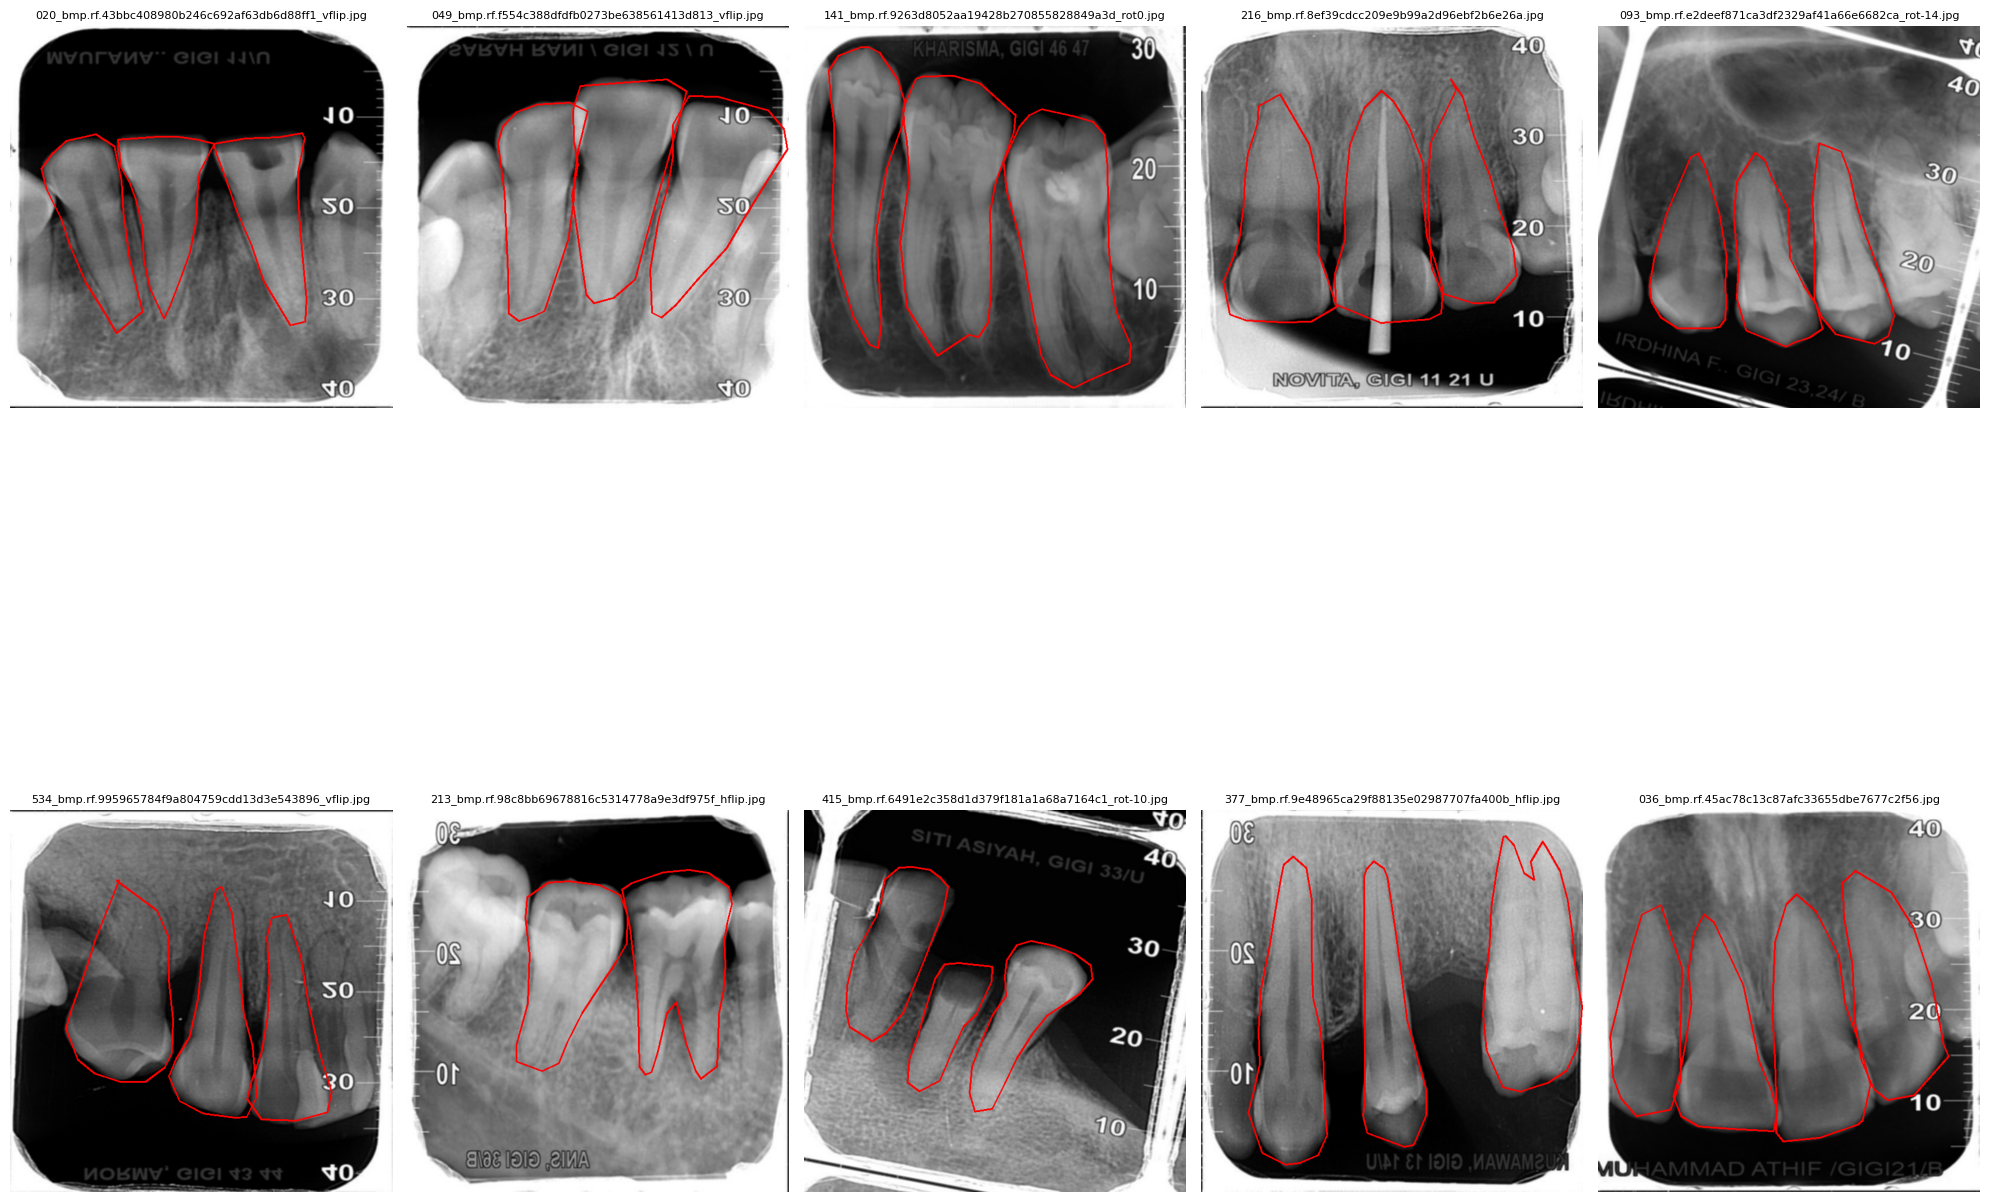

In [5]:
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def draw_yolo_polygons(image_path, label_path):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape

    with open(label_path, 'r') as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 3 or len(parts) % 2 == 0:
            continue  # Skip malformed lines

        points = list(map(float, parts[1:]))
        poly_points = [(int(x * w), int(y * h)) for x, y in zip(points[::2], points[1::2])]
        if len(poly_points) > 1:
            cv2.polylines(image, [np.array(poly_points, dtype=np.int32)], isClosed=True, color=(255, 0, 0), thickness=2)

    return image

# === Config ===
SPLIT = 'train'  # change to 'valid' or 'test' as needed
BASE_DIR = Path("yolo_dataset_enhanced_augmented_split")
IMG_DIR = BASE_DIR / SPLIT / "images"
LBL_DIR = BASE_DIR / SPLIT / "labels"
NUM_SAMPLES = 10

# === Get random samples ===
all_images = list(IMG_DIR.glob("*.jpg"))
samples = random.sample(all_images, min(NUM_SAMPLES, len(all_images)))

# === Plot them ===
plt.figure(figsize=(20, 20))
cols = 5
rows = (len(samples) + cols - 1) // cols

for idx, img_path in enumerate(samples):
    lbl_path = LBL_DIR / (img_path.stem + ".txt")
    vis_img = draw_yolo_polygons(img_path, lbl_path)

    plt.subplot(rows, cols, idx + 1)
    plt.imshow(vis_img)
    plt.title(img_path.name, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
pip install ultralytics

  Using cached ultralytics-8.3.168-py3-none-any.whl.metadata (37 kB)
  Using cached opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl.metadata (19 kB)
  Using cached ultralytics_thop-2.0.14-py3-none-any.whl.metadata (9.4 kB)
Using cached ultralytics-8.3.168-py3-none-any.whl (1.0 MB)
Using cached opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl (39.0 MB)
Using cached ultralytics_thop-2.0.14-py3-none-any.whl (26 kB)

   ---------------------------------------- 0/3 [opencv-python]
   ---------------------------------------- 0/3 [opencv-python]
   ---------------------------------------- 0/3 [opencv-python]
   ---------------------------------------- 0/3 [opencv-python]
   ---------------------------------------- 0/3 [opencv-python]
   ---------------------------------------- 0/3 [opencv-python]
   ---------------------------------------- 0/3 [opencv-python]
   ---------------------------------------- 0/3 [opencv-python]
   ------------- -------------------------- 1/3 [ultralytics-thop]
   --

In [ ]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Tooth Segmentation – Training a YOLOv8 segmentation model with TFLite export and comprehensive logging
'''
    This script trains a YOLOv8 segmentation model to automatically segment individual teeth from dental X-ray images. 
    The model is designed for instance segmentation, which detects objects (teeth) and predicts their pixel-wise masks. 
    Using a dataset of labeled X-rays, the model learns to identify and separate each tooth.
    Key training parameters like optimizer, learning rate, and momentum are adjusted for optimal performance.
    
    The script uses the nano (n) version of YOLOv8, which is the smallest and fastest model variant,
    making it suitable for mobile deployment while still maintaining acceptable segmentation quality.
    
    After training, the script exports the model to TFLite format for efficient mobile inference,
    logs training progress to text files, saves training summary to CSV, and provides comprehensive
    evaluation metrics including precision, accuracy, recall, mAP, IoU, and confusion matrix.
'''

import os
import csv
import logging
import pandas as pd
import numpy as np
from datetime import datetime
from ultralytics import YOLO
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Setup logging
def setup_logging():
    """Setup comprehensive logging for training process"""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Create logs directory if it doesn't exist
    os.makedirs("training_logs", exist_ok=True)
    
    # Setup text file logging
    log_filename = f"training_logs/training_log_{timestamp}.txt"
    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s - %(levelname)s - %(message)s',
        handlers=[
            logging.FileHandler(log_filename),
            logging.StreamHandler()  # Also print to console
        ]
    )
    
    return timestamp, log_filename

def save_training_summary_csv(results, timestamp, model_path):
    """Save training summary to CSV file"""
    csv_filename = f"training_logs/training_summary_{timestamp}.csv"
    
    # Extract key metrics from results
    summary_data = {
        'timestamp': [timestamp],
        'model_path': [model_path],
        'final_box_loss': [results.box_loss if hasattr(results, 'box_loss') else 'N/A'],
        'final_cls_loss': [results.cls_loss if hasattr(results, 'cls_loss') else 'N/A'],
        'final_dfl_loss': [results.dfl_loss if hasattr(results, 'dfl_loss') else 'N/A'],
        'final_seg_loss': [results.seg_loss if hasattr(results, 'seg_loss') else 'N/A'],
        'best_fitness': [results.fitness if hasattr(results, 'fitness') else 'N/A'],
        'training_time': [results.training_time if hasattr(results, 'training_time') else 'N/A']
    }
    
    # Add mAP metrics if available
    if hasattr(results, 'maps'):
        summary_data['mAP50'] = [results.maps[0] if len(results.maps) > 0 else 'N/A']
        summary_data['mAP50_95'] = [results.maps[1] if len(results.maps) > 1 else 'N/A']
    
    df = pd.DataFrame(summary_data)
    df.to_csv(csv_filename, index=False)
    logging.info(f"Training summary saved to: {csv_filename}")

def evaluate_model_detailed(model, data_yaml_path):
    """Perform detailed evaluation and generate comprehensive metrics"""
    logging.info("Starting detailed model evaluation...")
    
    # Run validation
    results = model.val(data=data_yaml_path, plots=True, save_json=True)
    
    # Extract detailed metrics
    metrics = {
        'Precision (P)': results.box.p.mean() if hasattr(results.box, 'p') else 'N/A',
        'Recall (R)': results.box.r.mean() if hasattr(results.box, 'r') else 'N/A',
        'mAP@0.5': results.box.map50 if hasattr(results.box, 'map50') else 'N/A',
        'mAP@0.5:0.95': results.box.map if hasattr(results.box, 'map') else 'N/A',
        'Mean IoU': results.seg.map if hasattr(results, 'seg') and hasattr(results.seg, 'map') else 'N/A'
    }
    
    # Log metrics
    logging.info("EVALUATION METRICS")
    for metric, value in metrics.items():
        if value != 'N/A':
            logging.info(f"{metric}: {value:.4f}")
        else:
            logging.info(f"{metric}: {value}")
    
    # Generate and save confusion matrix if possible
    try:
        if hasattr(results, 'confusion_matrix') and results.confusion_matrix is not None:
            plot_confusion_matrix(results.confusion_matrix, timestamp)
        else:
            logging.warning("Confusion matrix not available in results")
    except Exception as e:
        logging.warning(f"Could not generate confusion matrix: {e}")
    
    return metrics

def plot_confusion_matrix(cm_data, timestamp):
    """Plot and save confusion matrix"""
    try:
        plt.figure(figsize=(10, 8))
        
        # If cm_data is from YOLO, it might need processing
        if hasattr(cm_data, 'matrix'):
            cm = cm_data.matrix
        else:
            cm = cm_data
            
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion Matrix - Tooth Segmentation')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        
        # Save confusion matrix
        cm_filename = f"training_logs/confusion_matrix_{timestamp}.png"
        plt.savefig(cm_filename, dpi=300, bbox_inches='tight')
        plt.close()
        
        logging.info(f"Confusion matrix saved to: {cm_filename}")
        
    except Exception as e:
        logging.error(f"Error plotting confusion matrix: {e}")

def export_to_tflite(model, timestamp):
    """Export trained model to TFLite format"""
    try:
        logging.info("Starting TFLite export...")
        
        # Export to TFLite
        tflite_path = model.export(
            format='tflite',
            imgsz=640,  # Input image size
            int8=True,  # Use int8 quantization for smaller model size
            data='yolo_dataset_enhanced_augmented_split/data.yaml'  # Needed for calibration
        )
        
        logging.info(f"Model successfully exported to TFLite: {tflite_path}")
        
        # Also save a copy with timestamp
        import shutil
        timestamped_path = f"training_logs/tooth_segmentation_model_{timestamp}.tflite"
        shutil.copy2(tflite_path, timestamped_path)
        logging.info(f"Timestamped copy saved to: {timestamped_path}")
        
        return tflite_path, timestamped_path
        
    except Exception as e:
        logging.error(f"TFLite export failed: {e}")
        return None, None

# Main training execution
if __name__ == "__main__":
    # Setup logging
    timestamp, log_file = setup_logging()
    logging.info("Starting YOLOv8 tooth segmentation training...")
    
    # Load the YOLOv8 instance segmentation model
    logging.info("Loading YOLOv8n-seg model...")
    model = YOLO("yolov8n-seg.pt")
    
    try:
        # Train the model
        logging.info("Starting model training...")
        results = model.train(
            data="yolo_dataset_enhanced_augmented_split/data.yaml",  # Updated path
            epochs=100,                        # Number of epochs
            batch=8,                          # Batch size
            device="cpu",                     # Use CPU for training
            
            # Optimization parameters
            optimizer="AdamW",                # Use AdamW optimizer
            lr0=0.001,                        # Initial learning rate
            momentum=0.937,                   # Momentum for the optimizer
            weight_decay=0.0005,              # Regularization term
            warmup_epochs=3,                  # Number of epochs for warmup
            warmup_momentum=0.8,              # Momentum during warmup
            warmup_bias_lr=0.1,               # Bias learning rate during warmup
            
            # CPU-specific optimizations
            workers=4,                        # Number of worker threads for data loading
            cache=False,                      # Don't cache images in RAM
            plots=True,                       # Generate performance plots
            
            # Segmentation improvements
            overlap_mask=True,                # Improves mask quality for overlapping teeth
            mask_ratio=4,                     # Controls mask resolution
            iou=0.7,                          # IoU threshold for NMS
            
            # Loss function adjustments
            box=0.5,                          # Box loss weight
            cls=0.5,                          # Classification loss weight 
            dfl=1.0,                          # Distribution focal loss weight
            
            # Validation and saving parameters
            val=True,                         # Run validation during training
            save=True,                        # Save model checkpoints
            save_period=5,                    # Save model every 5 epochs
            
            # Project and name for organized output
            project="tooth_segmentation_runs",
            name=f"train_{timestamp}"
        )
        
        logging.info("Training completed successfully!")
        
        # Save training summary to CSV
        save_training_summary_csv(results, timestamp, str(model.ckpt_path) if hasattr(model, 'ckpt_path') else 'N/A')
        
        # Perform detailed evaluation
        evaluation_metrics = evaluate_model_detailed(model, "yolo_dataset_enhanced_augmented_split/data.yaml")
        
        # Export to TFLite
        tflite_path, timestamped_tflite = export_to_tflite(model, timestamp)
        
        # Final summary
        logging.info("TRAINING COMPLETE")
        logging.info(f"Log file: {log_file}")
        logging.info(f"Training summary CSV: training_logs/training_summary_{timestamp}.csv")
        if tflite_path:
            logging.info(f"TFLite model: {tflite_path}")
            logging.info(f"Timestamped TFLite: {timestamped_tflite}")
        
        print("\n" + "="*50)
        print("FINAL EVALUATION METRICS:")
        print("="*50)
        for metric, value in evaluation_metrics.items():
            if value != 'N/A':
                print(f"{metric}: {value:.4f}")
            else:
                print(f"{metric}: {value}")
        print("="*50)
        
    except Exception as e:
        logging.error(f"Training failed with error: {e}")
        raise e

2025-08-17 11:29:15,037 - INFO - Starting YOLOv8 tooth segmentation training...
2025-08-17 11:29:15,039 - INFO - Loading YOLOv8n-seg model...
2025-08-17 11:29:16,578 - INFO - Starting model training...


New https://pypi.org/project/ultralytics/8.3.179 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.143  Python-3.11.9 torch-2.7.0+cpu CPU (13th Gen Intel Core(TM) i7-1355U)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=0.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset_enhanced_augmented_split/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train_20250817_112915,

train: Scanning C:\Users\n3des\Desktop\New folder\yolo_dataset_enhanced_augmented_split\train\labels.cache... 2083 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2083/2083 [00:00<?, ?it/s]

val: Fast image access  (ping: 0.40.1 ms, read: 9.30.9 MB/s, size: 88.5 KB)



C:\Users\n3des\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
val: Scanning C:\Users\n3des\Desktop\New folder\yolo_dataset_enhanced_augmented_split\valid\labels.cache... 260 images, 0 backgrounds, 0 corrupt: 100%|██████████| 260/260 [00:00<?, ?it/s]

...

Ultralytics 8.3.143  Python-3.11.9 torch-2.7.0+cpu CPU (13th Gen Intel Core(TM) i7-1355U)
YOLOv8n-seg summary (fused): 85 layers, 3,258,259 parameters, 0 gradients, 12.0 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 836.6278.2 MB/s, size: 70.2 KB)


val: Scanning C:\Users\n3des\Desktop\New folder\yolo_dataset_enhanced_augmented_split\valid\labels.cache... 260 images, 0 backgrounds, 0 corrupt: 100%|██████████| 260/260 [00:00<?, ?it/s]
C:\Users\n3des\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95):   0%|          | 0/33 [00:00<?, ?it/s]

requirements: Ultralytics requirement ['pycocotools>=2.0.6'] not found, attempting AutoUpdate...
WARNING Retry 1/2 failed: Command 'pip install --no-cache-dir "pycocotools>=2.0.6" ' returned non-zero exit status 1.
WARNING Retry 2/2 failed: Command 'pip install --no-cache-dir "pycocotools>=2.0.6" ' returned non-zero exit status 1.
WARNING requirements:  Command 'pip install --no-cache-dir "pycocotools>=2.0.6" ' returned non-zero exit status 1.


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95):   0%|          | 0/33 [00:25<?, ?it/s]
2025-08-18 12:33:26,639 - ERROR - Training failed with error: No module named 'pycocotools'


ModuleNotFoundError: No module named 'pycocotools'

In [1]:
%pip install pycocotools

Note: you may need to restart the kernel to use updated packages.


In [3]:
from ultralytics import YOLO

model = YOLO("tooth_segmentation_runs/train_20250817_112915/weights/best.pt")
results = model.val(data="yolo_dataset_enhanced_augmented_split/data.yaml")

Ultralytics 8.3.143  Python-3.11.9 torch-2.7.0+cpu CPU (13th Gen Intel Core(TM) i7-1355U)
YOLOv8n-seg summary (fused): 85 layers, 3,258,259 parameters, 0 gradients, 12.0 GFLOPs
val: Fast image access  (ping: 0.20.0 ms, read: 173.038.8 MB/s, size: 72.1 KB)


val: Scanning C:\Users\n3des\Desktop\New folder\yolo_dataset_enhanced_augmented_split\valid\labels.cache... 260 images, 0 backgrounds, 0 corrupt: 100%|██████████| 260/260 [00:00<?, ?it/s]
C:\Users\n3des\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:20<00:00,  1.21s/it]


                   all        260        777      0.983      0.996      0.994      0.867      0.983      0.996      0.994      0.796
Speed: 0.9ms preprocess, 69.7ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to runs\segment\val



image 1/1 c:\Users\n3des\Desktop\New folder\yolo_dataset_enhanced_augmented_split\train\images\001_bmp.rf.4232589cf89b1e92026cb20c082278e5_hflip.jpg: 640x640 4 objects, 111.8ms
Speed: 1.9ms preprocess, 111.8ms inference, 6.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to predictions_single\trial2_output2
1 label saved to predictions_single\trial2_output2\labels


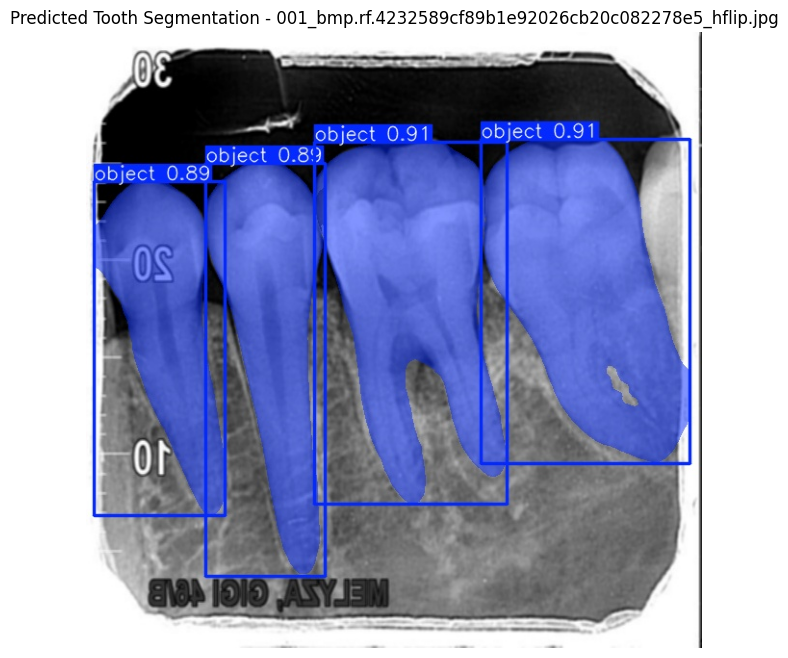

In [ ]:
import os
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# === Configuration ===
model_path = r"tooth_segmentation_runs/train_20250817_112915/weights/best.pt"
image_path = r"../trials/trial2.jpg"
save_output_dir = "trials"

# === Load the model ===
model = YOLO(model_path)

# === Run prediction ===
results = model.predict(
    source=image_path,
    save=True,
    save_txt=True,
    save_conf=True,
    save_crop=False,
    project=save_output_dir,
    name="trial2_output",
    imgsz=640,
    conf=0.5,
    iou=0.5,
    retina_masks=True
)

# === Visualize the result ===
# Get the base filename of the input image
input_filename = os.path.basename(image_path)

# Predicted image path (same filename as input)
result_img_path = f"{save_output_dir}/trial2_output/{input_filename}"

# Load and display
img = cv2.imread(result_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title(f"Predicted Tooth Segmentation - {input_filename}")
plt.axis("off")
plt.show()


Results saved to \trial2_output
1 label saved to \trial2_output\labels


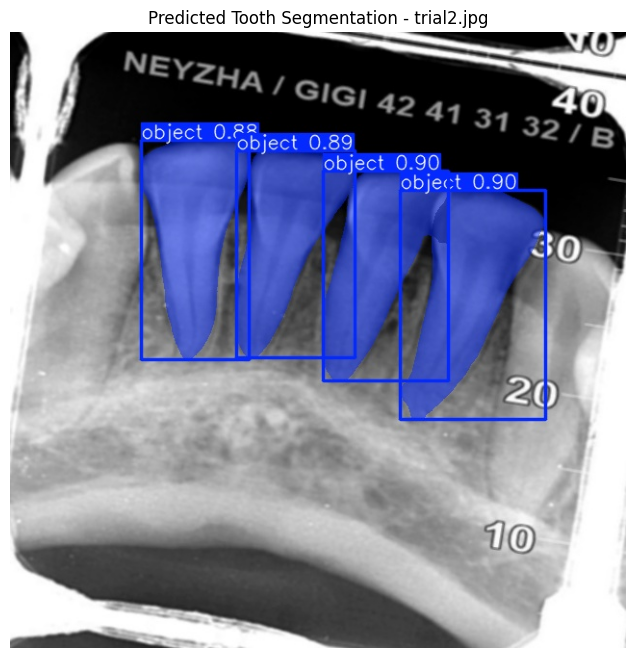

In [ ]:
# replace the model path and image path if you want to test the model.
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os

# === Configuration ===
model_path = "../tooth_segmentation_runs/train_20250817_112915/weights/best.pt"
image_path =  "../trials/trial2.jpg"
save_output_dir = "../trials"
output_name = "/trial2_output"

# === Load the model with correct task type
model = YOLO(model_path, task="segment")  # Set task to avoid 'detect' fallback

# === Run prediction (disable verbose output that requires class names)
results = model.predict(
    source=image_path,
    save=True,
    save_txt=True,
    save_conf=True,
    save_crop=False,
    project=save_output_dir,
    name=output_name,
    imgsz=640,
    conf=0.3,
    iou=0.5,
    retina_masks=True,
    verbose=False  # <--- disables .verbose() which causes crash
)

# === Visualize the result
result_img_path = os.path.join(save_output_dir, output_name, os.path.basename(image_path))

if os.path.exists(result_img_path):
    img = cv2.imread(result_img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.title("Predicted Tooth Segmentation - trial2.jpg")
    plt.axis("off")
    plt.show()
else:
    print(f"Prediction image not found: {result_img_path}")
